In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, regularizers

import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/ECE x ML/id_vg_characteristics/2nm/Simulated2/id_vg_grain_2nm_weff_60nm_lg8.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (202, 201)


,Voltage(V),I_d_1,I_d_2,I_d_3,I_d_4,I_d_5,I_d_6,I_d_7,I_d_8,I_d_9,...,I_d_191,I_d_192,I_d_193,I_d_194,I_d_195,I_d_196,I_d_197,I_d_198,I_d_199,I_d_200
0,-0.50,-2.561082e-21,-5.118202e-22,-2.049013e-21,5.104867e-22,-2.561109e-21,5.141741e-22,-5.104607e-22,-3.071810e-21,-2.048579e-21,...,-4.607012e-21,-1.026017e-21,-4.608069e-21,-2.048291e-21,4.702594e-26,-2.047672e-21,-3.582754e-21,-1.302420e-24,-2.047380e-21,-1.535200e-21
1,-0.50,-4.756136e-20,-5.626011e-20,4.665516e-20,1.132067e-19,-2.231623e-19,-8.339088e-20,1.070683e-19,4.050719e-20,-9.312578e-20,...,2.192047e-19,1.526599e-19,7.787366e-20,2.478254e-19,7.380964e-20,1.009061e-19,1.137235e-19,6.047325e-20,1.747225e-20,1.213829e-19
2,-0.49,2.140072e-19,2.273296e-19,2.283457e-19,3.118303e-19,1.249454e-19,1.940371e-19,1.930089e-19,1.884026e-19,1.433702e-19,...,1.709953e-19,1.827964e-19,2.554752e-19,1.776702e-19,2.242642e-19,2.165723e-19,-1.228400e-19,6.041744e-20,1.705014e-19,1.227586e-20
3,-0.48,6.363929e-19,5.887738e-19,5.652364e-19,5.048013e-19,4.152253e-19,5.780016e-19,5.160778e-19,5.406724e-19,4.827899e-19,...,3.205099e-19,4.561824e-19,5.442108e-19,4.259869e-19,5.636942e-19,4.131635e-19,2.570255e-19,4.264681e-19,5.611294e-19,2.989788e-19
4,-0.47,1.287072e-18,1.157026e-18,1.185739e-18,1.044885e-18,8.621774e-19,1.211802e-18,1.046994e-18,1.107893e-18,9.543044e-19,...,6.087432e-19,9.154126e-19,1.095097e-18,8.749866e-19,1.180103e-18,7.761288e-19,5.687965e-19,7.935435e-19,1.103279e-18,5.657570e-19


In [ ]:
# Remove unwanted columns
cols_to_drop = [c for c in df.columns if "Unnamed" in c or "Averge" in c]
df = df.drop(columns=cols_to_drop)

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (202, 201)


In [ ]:
voltage = df.iloc[:,0].values.reshape(-1,1)

print("Voltage range:", voltage.min(), "to", voltage.max())

Voltage range: -0.5 to 1.5


In [ ]:
results_df = pd.DataFrame()

results_df[df.columns[0]] = df.iloc[:,0]   # Voltage

In [ ]:
save_dir = "/content/drive/MyDrive/ECE x ML/id_vg_characteristics/2nm/Predicted"

os.makedirs(save_dir, exist_ok=True)

save_file = os.path.join(save_dir, "id_vg_grain_2nm_weff_60nm_lg8_predicted.csv")

print("Results will be saved to:", save_file)

Results will be saved to: /content/drive/MyDrive/ECE x ML/id_vg_characteristics/2nm/Predicted/id_vg_grain_2nm_weff_60nm_lg8_predicted.csv


In [ ]:
start_seed = 1

if os.path.exists(save_file):
    print("Checkpoint found. Loading previous results...")

    results_df = pd.read_csv(save_file)

    processed_cols = results_df.shape[1] - 1
    start_seed = processed_cols // 2 + 1

    print("Resuming from seed:", start_seed)
else:
    print("Starting fresh run.")

Checkpoint found. Loading previous results...
Resuming from seed: 181


Training loop including time analysis


In [ ]:
import time

# --- Timing Setup ---
seed_times = []
overall_start = time.time()

np.random.seed(42)
tf.random.set_seed(42)

eps = 1e-22

total_seeds = df.shape[1] - 1

for seed in range(start_seed, total_seeds + 1):
    # Start timer for this specific seed
    seed_start = time.time()

    print(f"\nProcessing Seed {seed}")

    try:
        # -----------------------------
        # Extract current column safely
        # -----------------------------
        y_series = pd.to_numeric(df.iloc[:, seed], errors="coerce")
        valid_mask = ~y_series.isna()

        X = voltage[valid_mask.values]
        y = y_series[valid_mask].values.reshape(-1,1)

        # -----------------------------
        # Physics-aware outlier removal
        # -----------------------------
        log_I = np.log10(np.abs(y) + eps)

        sub_mask = X.flatten() < -0.4
        log_I_sub = log_I[sub_mask]

        median = np.median(log_I_sub)
        mad = np.median(np.abs(log_I_sub - median))
        robust_sigma = 1.4826 * mad

        threshold = 2.5 * robust_sigma

        outliers = (np.abs(log_I - median) > threshold).flatten() & sub_mask

        X_clean = X[~outliers]
        y_clean = y[~outliers]

        # -----------------------------
        # Log target
        # -----------------------------
        y_log = np.log10(np.abs(y_clean) + eps)

        # If too few samples, skip seed
        if len(X_clean) < 20:
            print(f"Seed {seed} skipped (too few samples)")
            continue

        # -----------------------------
        # Train test split
        # -----------------------------
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_log, test_size=0.2, random_state=42
        )

        scaler = StandardScaler()

        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        # -----------------------------
        # Build ANN
        # -----------------------------
        model = tf.keras.Sequential([
            layers.Dense(64, activation="tanh",
                         kernel_regularizer=regularizers.l2(1e-4),
                         input_shape=(1,)),

            layers.Dense(64, activation="tanh",
                         kernel_regularizer=regularizers.l2(1e-4)),

            layers.Dense(32, activation="tanh",
                         kernel_regularizer=regularizers.l2(1e-4)),

            layers.Dense(1)
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(1e-3),
            loss="mse"
        )

        history = model.fit(
            X_train_s, y_train,
            epochs=500,
            batch_size=16,
            validation_split=0.2,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=50,
                    restore_best_weights=True
                ),
                tf.keras.callbacks.ReduceLROnPlateau(
                    monitor="val_loss",
                    factor=0.2,
                    patience=20
                )
            ],
            verbose=0
        )

        # -----------------------------
        # Predict on full voltage grid
        # -----------------------------
        X_full_s = scaler.transform(voltage)

        y_log_pred = model.predict(X_full_s, verbose=0).flatten()

        I_pred = 10 ** y_log_pred

        # -----------------------------
        # Save actual and predicted
        # -----------------------------
        actual_col = df.columns[seed]
        pred_col = f"{actual_col}_Pred"

        results_df[actual_col] = df.iloc[:, seed]
        results_df[pred_col] = I_pred

        # --- End timer for this seed ---
        seed_end = time.time()
        duration = seed_end - seed_start
        seed_times.append(duration)
        print(f"Seed {seed} completed in {duration:.2f}s")

        # -----------------------------
        # Save checkpoint every 10 seeds
        # -----------------------------
        if seed % 10 == 0:
            results_df.to_csv(save_file, index=False)
            print("Checkpoint saved.")

        tf.keras.backend.clear_session()

    except Exception as e:
        print(f"Seed {seed} skipped due to error: {e}")
        tf.keras.backend.clear_session()
        continue

# --- Final Time Metrics ---
overall_end = time.time()
total_time = overall_end - overall_start

print("\n" + "="*30)
print("TRAINING PERFORMANCE SUMMARY")
print("="*30)
print(f"Total Seeds Processed: {len(seed_times)}")
print(f"Total Training Time:   {total_time/60:.2f} minutes")
if len(seed_times) > 0:
    print(f"Average Time per Seed: {total_time/len(seed_times):.2f} seconds")
print("="*30)


Processing Seed 181


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Seed 181 completed in 51.75s

Processing Seed 182


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Seed 182 completed in 52.22s

Processing Seed 183


...

Seed 198 completed in 53.14s

Processing Seed 199


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Seed 199 completed in 52.48s

Processing Seed 200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Seed 200 completed in 52.65s
Checkpoint saved.

TRAINING PERFORMANCE SUMMARY
Total Seeds Processed: 20
Total Training Time:   17.53 minutes
Average Time per Seed: 52.60 seconds


In [ ]:
# np.random.seed(42)
# tf.random.set_seed(42)

# eps = 1e-22

# total_seeds = df.shape[1] - 1

# for seed in range(start_seed, total_seeds + 1):

#     print(f"\nProcessing Seed {seed}")

#     try:

#         # -----------------------------
#         # Extract current column safely
#         # -----------------------------
#         y_series = pd.to_numeric(df.iloc[:, seed], errors="coerce")
#         valid_mask = ~y_series.isna()

#         X = voltage[valid_mask.values]
#         y = y_series[valid_mask].values.reshape(-1,1)

#         # -----------------------------
#         # Physics-aware outlier removal
#         # -----------------------------
#         log_I = np.log10(np.abs(y) + eps)

#         sub_mask = X.flatten() < -0.4
#         log_I_sub = log_I[sub_mask]

#         median = np.median(log_I_sub)
#         mad = np.median(np.abs(log_I_sub - median))
#         robust_sigma = 1.4826 * mad

#         threshold = 2.5 * robust_sigma

#         outliers = (np.abs(log_I - median) > threshold).flatten() & sub_mask

#         X_clean = X[~outliers]
#         y_clean = y[~outliers]

#         # -----------------------------
#         # Log target
#         # -----------------------------
#         y_log = np.log10(np.abs(y_clean) + eps)

#         # If too few samples, skip seed
#         if len(X_clean) < 20:
#             print(f"Seed {seed} skipped (too few samples)")
#             continue

#         # -----------------------------
#         # Train test split
#         # -----------------------------
#         X_train, X_test, y_train, y_test = train_test_split(
#             X_clean, y_log, test_size=0.2, random_state=42
#         )

#         scaler = StandardScaler()

#         X_train_s = scaler.fit_transform(X_train)
#         X_test_s = scaler.transform(X_test)

#         # -----------------------------
#         # Build ANN
#         # -----------------------------
#         model = tf.keras.Sequential([
#             layers.Dense(64, activation="tanh",
#                          kernel_regularizer=regularizers.l2(1e-4),
#                          input_shape=(1,)),

#             layers.Dense(64, activation="tanh",
#                          kernel_regularizer=regularizers.l2(1e-4)),

#             layers.Dense(32, activation="tanh",
#                          kernel_regularizer=regularizers.l2(1e-4)),

#             layers.Dense(1)
#         ])

#         model.compile(
#             optimizer=tf.keras.optimizers.Adam(1e-3),
#             loss="mse"
#         )

#         history = model.fit(
#             X_train_s, y_train,
#             epochs=500,
#             batch_size=16,
#             validation_split=0.2,
#             callbacks=[
#                 tf.keras.callbacks.EarlyStopping(
#                     monitor="val_loss",
#                     patience=50,
#                     restore_best_weights=True
#                 ),
#                 tf.keras.callbacks.ReduceLROnPlateau(
#                     monitor="val_loss",
#                     factor=0.2,
#                     patience=20
#                 )
#             ],
#             verbose=0
#         )

#         # -----------------------------
#         # Predict on full voltage grid
#         # -----------------------------
#         X_full_s = scaler.transform(voltage)

#         y_log_pred = model.predict(X_full_s, verbose=0).flatten()

#         I_pred = 10 ** y_log_pred

#         # -----------------------------
#         # Save actual and predicted
#         # -----------------------------
#         actual_col = df.columns[seed]
#         pred_col = f"{actual_col}_Pred"

#         results_df[actual_col] = df.iloc[:, seed]
#         results_df[pred_col] = I_pred

#         # -----------------------------
#         # Save checkpoint every 10 seeds
#         # -----------------------------
#         if seed % 10 == 0:
#             results_df.to_csv(save_file, index=False)
#             print("Checkpoint saved.")

#         tf.keras.backend.clear_session()

#     except Exception as e:
#         print(f"Seed {seed} skipped due to error: {e}")
#         tf.keras.backend.clear_session()
#         continue


Processing Seed 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Processing Seed 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Processing Seed 3


...


Processing Seed 199


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/tmp/ipykernel_11320/3769698581.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results_df[actual_col] = df.iloc[:, seed]
/tmp/ipykernel_11320/3769698581.py:122: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = fram


Processing Seed 200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/tmp/ipykernel_11320/3769698581.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results_df[actual_col] = df.iloc[:, seed]
/tmp/ipykernel_11320/3769698581.py:122: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = fram

Checkpoint saved.


In [ ]:
results_df.to_csv(save_file, index=False)

print("All seeds processed.")
print("Final results saved to:", save_file)

All seeds processed.
Final results saved to: /content/drive/MyDrive/ECE x ML/id_vg_characteristics/2nm/Predicted/id_vg_grain_2nm_weff_60nm_lg8_predicted.csv


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/ECE x ML/id_vg_characteristics/2nm/Predicted/id_vg_grain_2nm_weff_60nm_lg8_predicted.csv"

results = pd.read_csv(file_path)

# find prediction columns
pred_cols = [c for c in results.columns if "_Pred" in c]

num_trained = len(pred_cols)

print("Number of seeds successfully trained:", num_trained)

total_seeds = 200
print("Total seeds expected:", total_seeds)

print("Skipped seeds:", total_seeds - num_trained)

Number of seeds successfully trained: 200
Total seeds expected: 200
Skipped seeds: 0


In [ ]:
trained_seeds = []

for col in pred_cols:
    # New format: 'I_d_1_Pred' -> split by '_' gives ['I', 'd', '1', 'Pred']
    # We take index 2, which is the number
    try:
        parts = col.split("_")
        seed_num = int(parts[2])
        trained_seeds.append(seed_num)
    except (IndexError, ValueError):
        print(f"Could not parse seed number from column: {col}")

all_seeds = list(range(1, total_seeds + 1))
skipped = sorted(set(all_seeds) - set(trained_seeds))

print("Number of seeds successfully trained:", len(trained_seeds))
print("Skipped seeds:", skipped)

Number of seeds successfully trained: 200
Skipped seeds: []


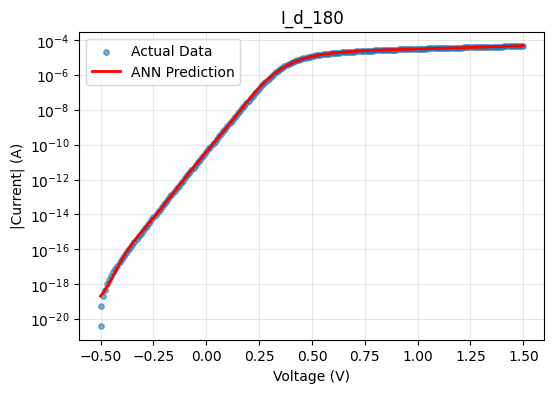

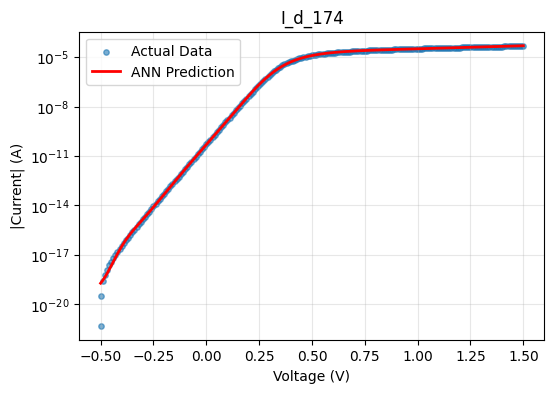

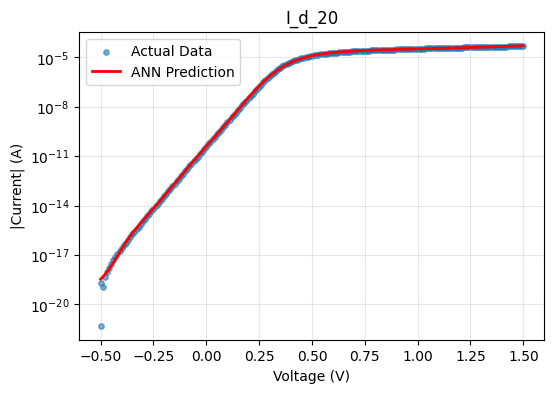

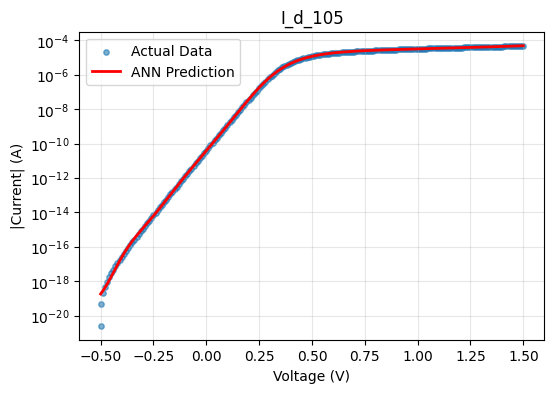

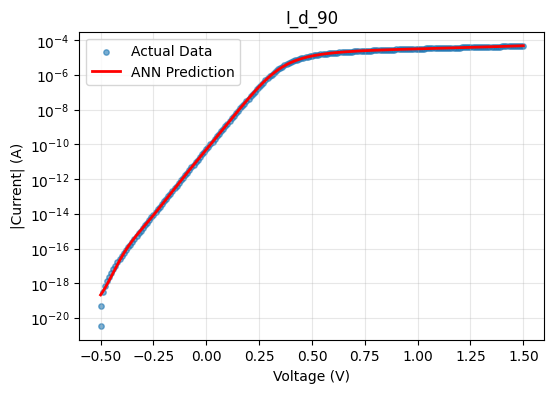

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# load results again
file_path = "/content/drive/MyDrive/ECE x ML/id_vg_characteristics/2nm/Predicted/id_vg_grain_2nm_weff_60nm_lg8_predicted.csv"
results = pd.read_csv(file_path)

# voltage column
voltage = results.iloc[:,0].values

# prediction columns
pred_cols = [c for c in results.columns if "_Pred" in c]

# randomly choose seeds to plot
num_plots = 5
random_preds = random.sample(pred_cols, num_plots)

for pred_col in random_preds:

    actual_col = pred_col.replace("_Pred","")

    I_actual = np.abs(results[actual_col].values)
    I_pred = np.abs(results[pred_col].values)

    plt.figure(figsize=(6,4))

    plt.scatter(voltage, I_actual, s=15, alpha=0.6, label="Actual Data")
    plt.plot(voltage, I_pred, color="red", linewidth=2, label="ANN Prediction")

    plt.yscale("log")

    plt.xlabel("Voltage (V)")
    plt.ylabel("|Current| (A)")
    plt.title(actual_col)

    plt.legend()
    plt.grid(True, which="both", alpha=0.3)

    plt.show()

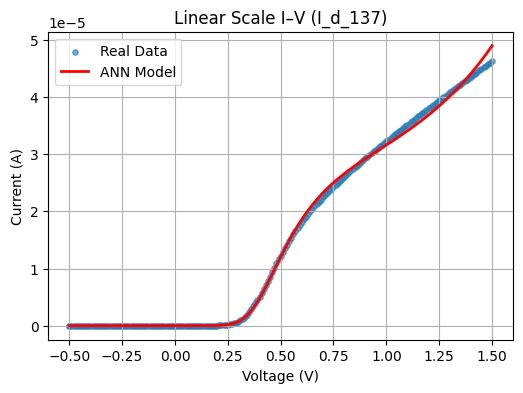

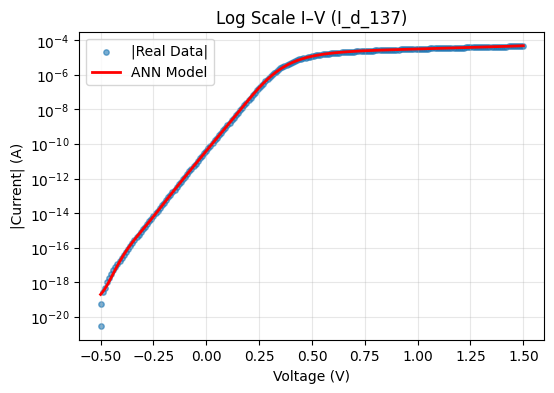

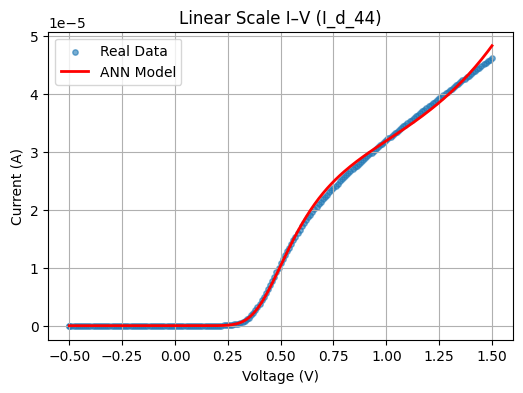

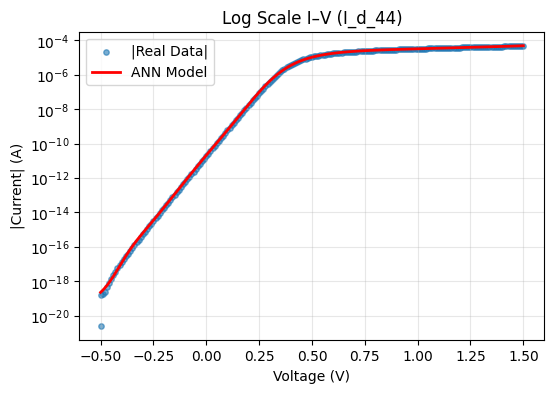

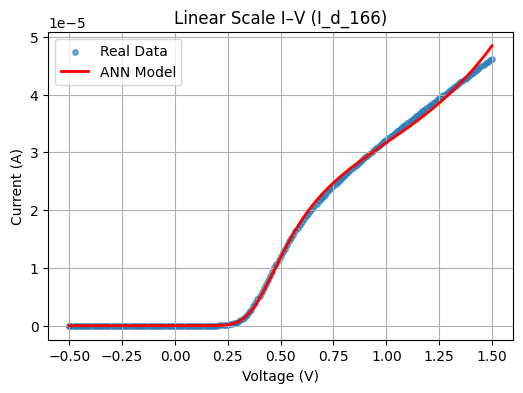

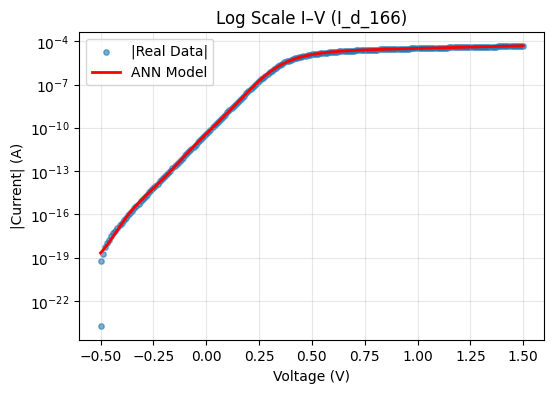

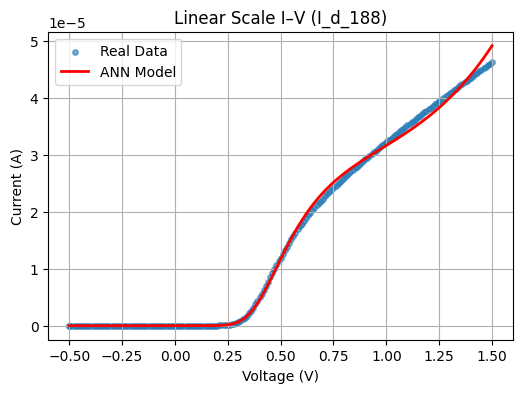

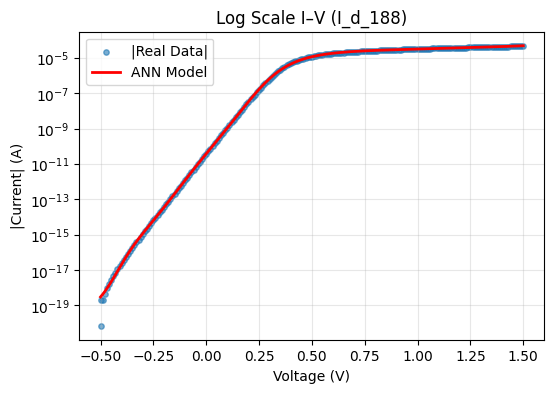

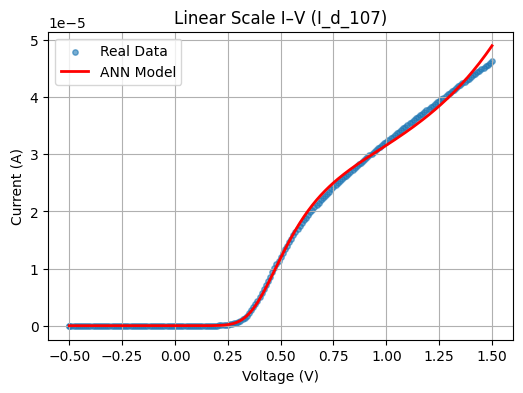

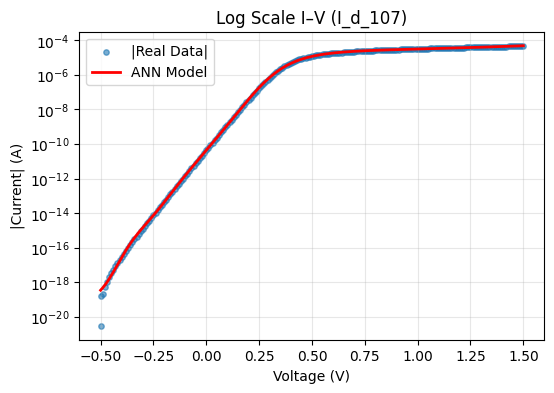

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# load results
file_path = "/content/drive/MyDrive/ECE x ML/id_vg_characteristics/2nm/Predicted/id_vg_grain_2nm_weff_60nm_lg8_predicted.csv"
results = pd.read_csv(file_path)

# voltage
voltage = results.iloc[:,0].values

# prediction columns
pred_cols = [c for c in results.columns if "_Pred" in c]

# randomly choose seeds
num_plots = 5
random_preds = random.sample(pred_cols, num_plots)

for pred_col in random_preds:

    actual_col = pred_col.replace("_Pred","")

    I_actual = results[actual_col].values
    I_pred = results[pred_col].values

    # -----------------------------
    # Linear Scale Plot
    # -----------------------------
    plt.figure(figsize=(6,4))

    plt.scatter(voltage, I_actual, s=15, alpha=0.6, label="Real Data")
    plt.plot(voltage, I_pred, color="red", linewidth=2, label="ANN Model")

    plt.xlabel("Voltage (V)")
    plt.ylabel("Current (A)")
    plt.title(f"Linear Scale I–V ({actual_col})")

    plt.legend()
    plt.grid(True)

    plt.show()

    # -----------------------------
    # Log Scale Plot
    # -----------------------------
    plt.figure(figsize=(6,4))

    plt.scatter(voltage, np.abs(I_actual), s=15, alpha=0.6, label="|Real Data|")
    plt.plot(voltage, np.abs(I_pred), color="red", linewidth=2, label="ANN Model")

    plt.yscale("log")

    plt.xlabel("Voltage (V)")
    plt.ylabel("|Current| (A)")
    plt.title(f"Log Scale I–V ({actual_col})")

    plt.legend()
    plt.grid(True, which="both", alpha=0.3)

    plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Setup the 'separate' folder inside the 'Predicted' directory
separate_dir = os.path.join(save_dir, "separate")
os.makedirs(separate_dir, exist_ok=True)

# Generate the specific filenames for training and testing
# This takes '...weff52_predicted' and adds '_training' or '_testing'
base_name_only = os.path.basename(save_file).replace(".csv", "")
train_save_path = os.path.join(separate_dir, f"{base_name_only}_training.csv")
test_save_path = os.path.join(separate_dir, f"{base_name_only}_testing.csv")

# 2. Prepare for splitting
# Get the shared Voltage column
voltage = results_df.iloc[:, 0].values
voltage_col_name = results_df.columns[0]

# Identify Actual vs Predicted columns using the new standardized names
# e.g., 'I_d_1' and 'I_d_1_Pred'
actual_cols = [c for c in results_df.columns if c.startswith('I_d_') and not c.endswith('_Pred')]
pred_cols = [f"{c}_Pred" for c in actual_cols]

# Initialize the split DataFrames
df_train = pd.DataFrame({voltage_col_name: voltage})
df_test = pd.DataFrame({voltage_col_name: voltage})

def get_exact_split_indices(v_arr, i_arr):
    """
    Exact replication of the physics-aware logic from your training loop.
    """
    eps = 1e-22
    y_vals = pd.to_numeric(i_arr, errors="coerce")
    valid_mask = ~np.isnan(y_vals)

    indices = np.where(valid_mask)[0]
    X_valid = v_arr[valid_mask].reshape(-1, 1)
    y_valid = y_vals[valid_mask].reshape(-1, 1)

    # Physics-aware outlier removal
    log_I = np.log10(np.abs(y_valid) + eps)
    sub_mask = (X_valid < -0.4).flatten()
    log_I_sub = log_I[sub_mask]

    if len(log_I_sub) > 0:
        median = np.median(log_I_sub)
        mad = np.median(np.abs(log_I_sub - median))
        robust_sigma = 1.4826 * mad
        threshold = 2.5 * robust_sigma
        outliers = (np.abs(log_I - median) > threshold).flatten() & sub_mask
        idx_clean = indices[~outliers]
    else:
        idx_clean = indices

    if len(idx_clean) < 20:
        return None, None

    # REPLICATE SPLIT: Uses random_state=42 and test_size=0.2 exactly like training
    idx_train, idx_test = train_test_split(idx_clean, test_size=0.2, random_state=42)
    return idx_train, idx_test

# 3. Iterate and Separate
print(f"Splitting {len(actual_cols)} seeds into Train and Test sets...")

for actual_col, pred_col in zip(actual_cols, pred_cols):
    if pred_col not in results_df.columns:
        continue # Skip seeds that weren't trained

    current_actual = results_df[actual_col].values
    current_pred = results_df[pred_col].values

    idx_train, idx_test = get_exact_split_indices(voltage, current_actual)

    # Create empty arrays filled with NaN
    train_y, train_p = np.full(len(voltage), np.nan), np.full(len(voltage), np.nan)
    test_y, test_p = np.full(len(voltage), np.nan), np.full(len(voltage), np.nan)

    if idx_train is not None:
        # Assign values to the specific split indices
        train_y[idx_train] = current_actual[idx_train]
        train_p[idx_train] = current_pred[idx_train]
        test_y[idx_test] = current_actual[idx_test]
        test_p[idx_test] = current_pred[idx_test]

    # Add to result dataframes
    df_train[actual_col] = train_y
    df_train[pred_col] = train_p
    df_test[actual_col] = test_y
    df_test[pred_col] = test_p

# 4. Save to the new 'separate' folder
df_train.to_csv(train_save_path, index=False)
df_test.to_csv(test_save_path, index=False)

print("\nSuccess! Files saved in 'Predicted/separate/':")
print(f"- {os.path.basename(train_save_path)}")
print(f"- {os.path.basename(test_save_path)}")

Splitting 200 seeds into Train and Test sets...


/tmp/ipykernel_1119/232002204.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[pred_col] = train_p
/tmp/ipykernel_1119/232002204.py:91: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test[pred_col] = test_p
/tmp/ipykernel_1119/232002204.py:88: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()


Success! Files saved in 'Predicted/separate/':
- id_vg_grain_2nm_weff_60nm_lg8_predicted_training.csv
- id_vg_grain_2nm_weff_60nm_lg8_predicted_testing.csv


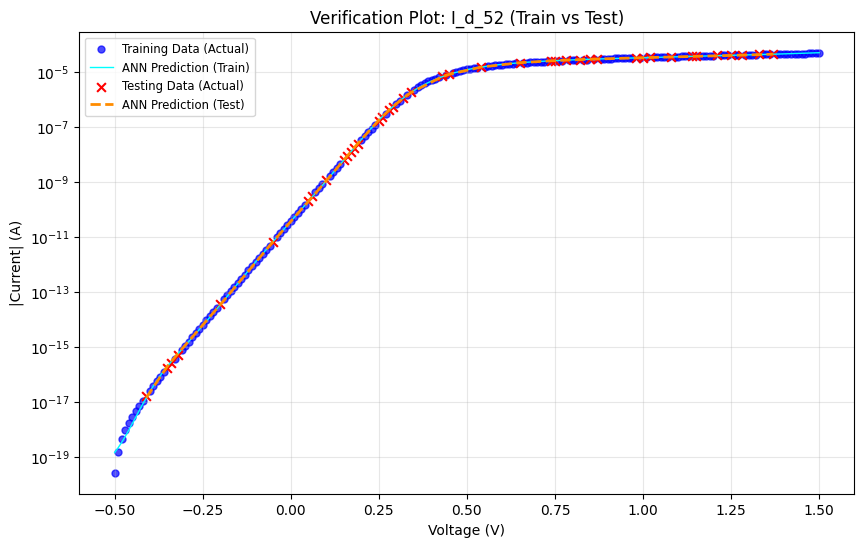

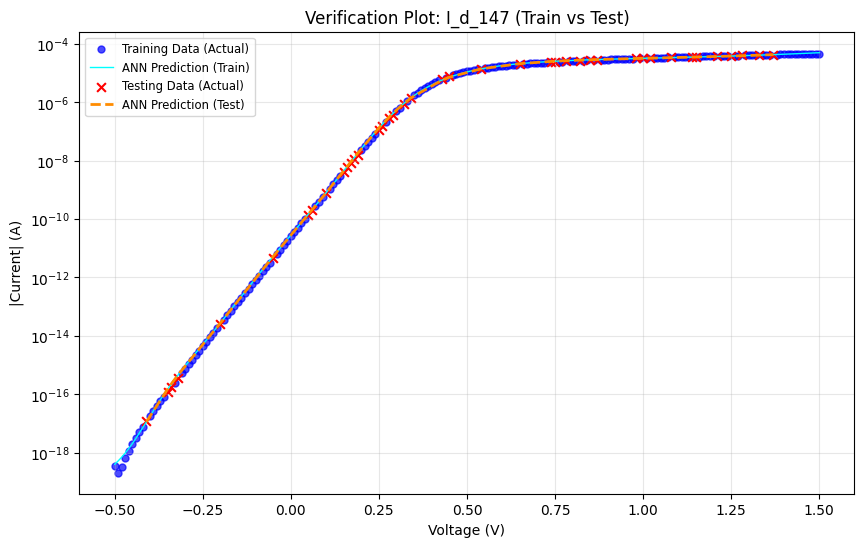

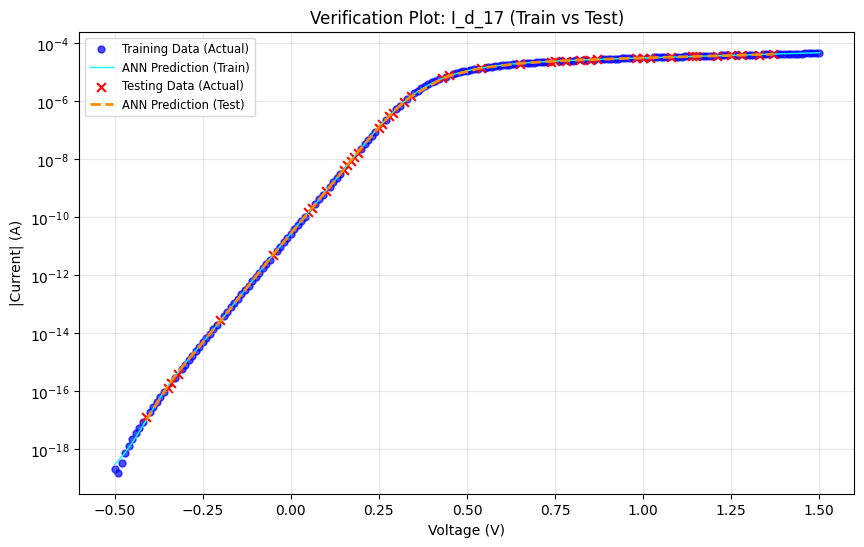

Verification plots complete. Blue dots were used for training, Red 'x' were hidden from the model.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import os

# 1. Define the paths to the newly created separate files
# (These variables should already be in your memory if you just ran the previous block)
# If not, you can manually paste the paths here.
train_path = train_save_path
test_path = test_save_path

# Load the split datasets
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# 2. Get the shared Voltage column
voltage = df_train.iloc[:, 0].values

# 3. Identify seed columns (e.g., I_d_1, I_d_2...)
# We look for columns that don't end in '_Pred' and aren't the Voltage column
seed_cols = [c for c in df_train.columns if c.startswith('I_d_') and not c.endswith('_Pred')]

# 4. Randomly select 3 seeds to verify
num_samples = 3
random_seeds = random.sample(seed_cols, min(num_samples, len(seed_cols)))

for seed in random_seeds:
    pred_col = f"{seed}_Pred"

    # Extract Actual and Predicted for Train
    y_train_act = np.abs(df_train[seed])
    y_train_pred = np.abs(df_train[pred_col])

    # Extract Actual and Predicted for Test
    y_test_act = np.abs(df_test[seed])
    y_test_pred = np.abs(df_test[pred_col])

    # Create the plot
    plt.figure(figsize=(10, 6))

    # --- Plot Training Data ---
    plt.scatter(voltage, y_train_act, color='blue', s=25, alpha=0.7, label='Training Data (Actual)')
    # Overlay Training Prediction (using a line to see the model trend)
    # We drop NaNs to make the line continuous for the plot
    mask_train = ~np.isnan(y_train_pred)
    plt.plot(voltage[mask_train], y_train_pred[mask_train], color='cyan', linewidth=1, label='ANN Prediction (Train)')

    # --- Plot Testing Data ---
    plt.scatter(voltage, y_test_act, color='red', marker='x', s=40, label='Testing Data (Actual)')
    # Overlay Testing Prediction
    mask_test = ~np.isnan(y_test_pred)
    plt.plot(voltage[mask_test], y_test_pred[mask_test], color='darkorange', linestyle='--', linewidth=2, label='ANN Prediction (Test)')

    # Formatting
    plt.yscale('log')
    plt.xlabel('Voltage (V)')
    plt.ylabel('|Current| (A)')
    plt.title(f"Verification Plot: {seed} (Train vs Test)")
    plt.legend(loc='best', fontsize='small')
    plt.grid(True, which="both", alpha=0.3)

    plt.show()

print("Verification plots complete. Blue dots were used for training, Red 'x' were hidden from the model.")

In [ ]:
import time
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

# 1. Initialize metrics and timing storage
metrics_list = []
eps = 1e-22

start_total_time = time.time()

print("Analyzing Accuracy Metrics and Computational Performance...")

for actual_col in actual_cols:
    seed_start_time = time.time()
    pred_col = f"{actual_col}_Pred"

    if pred_col not in results_df.columns:
        continue

    # Identify the Test split for evaluation
    idx_train, idx_test = get_exact_split_indices(voltage, results_df[actual_col].values)

    if idx_test is not None:
        y_true = results_df[actual_col].values[idx_test]
        y_pred = results_df[pred_col].values[idx_test]

        # --- Accuracy Metrics (Log Scale) ---
        log_y_true = np.log10(np.abs(y_true) + eps)
        log_y_pred = np.log10(np.abs(y_pred) + eps)

        r2 = r2_score(log_y_true, log_y_pred)
        rmse = np.sqrt(mean_squared_error(log_y_true, log_y_pred))
        mae = mean_absolute_error(log_y_true, log_y_pred)

        seed_end_time = time.time()
        seed_duration = seed_end_time - seed_start_time

        metrics_list.append({
            "Seed": actual_col,
            "R2_Score_Log": r2,
            "RMSE_Log": rmse,
            "MAE_Log": mae,
            "Execution_Time_Sec": seed_duration
        })

end_total_time = time.time()
total_duration = end_total_time - start_total_time

# 2. Create Summary DataFrame
performance_df = pd.DataFrame(metrics_list)

# 3. Calculate Overall Performance
avg_r2 = performance_df["R2_Score_Log"].mean()
avg_rmse = performance_df["RMSE_Log"].mean()
avg_time_per_seed = performance_df["Execution_Time_Sec"].mean()

print("\n" + "="*35)
print("Computational & Accuracy Summary")
print("="*35)
print(f"Total Seeds Evaluated:   {len(performance_df)}")
print(f"Average R2 Score (Log):  {avg_r2:.4f}")
print(f"Average RMSE (Log):      {avg_rmse:.4f}")
print(f"Average Time per Seed:   {avg_time_per_seed:.2f} seconds")
print(f"Total Execution Time:    {total_duration/60:.2f} minutes")
print("="*35)

# Display the performance table
performance_df.head(10)

Analyzing Accuracy Metrics and Computational Performance...

Computational & Accuracy Summary
Total Seeds Evaluated:   200
Average R2 Score (Log):  0.9999
Average RMSE (Log):      0.0265
Average Time per Seed:   0.00 seconds
Total Execution Time:    0.01 minutes


,Seed,R2_Score_Log,RMSE_Log,MAE_Log,Execution_Time_Sec
0,I_d_1,0.999959,0.022574,0.015910,0.004396
1,I_d_2,0.999924,0.030959,0.022880,0.002721
2,I_d_3,0.999946,0.026068,0.019762,0.002729
3,I_d_4,0.999949,0.025444,0.016177,0.002489
4,I_d_5,0.999932,0.029507,0.018527,0.002506
5,I_d_6,0.999949,0.025356,0.015711,0.002428
6,I_d_7,0.999970,0.019643,0.013923,0.003134
7,I_d_8,0.999950,0.025059,0.016670,0.002396
8,I_d_9,0.999932,0.029473,0.024832,0.002480
9,I_d_10,0.999955,0.024033,0.016712,0.001963
